# 2D PINN: Glomerular Filtration Simulation
This notebook acts as an interactive walkthrough of the 2D Physics-Informed Neural Network (PINN) training and visualization. The core physics engine and neural network architecture are cleanly separated into the `src/` directory to maintain software engineering standards.

## 0. Environment Setup
Run this cell to ensure all required libraries are installed directly into the notebook's active kernel.

In [ ]:
%pip install torch numpy matplotlib scipy

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.train import train_pinn

# Ensure plots display inline
%matplotlib inline


## 1. Normotensive State (Healthy Simulation)
We train the model with normal hydrostatic pressure ($u_{max}=1.0$) and a healthy filtration coefficient ($k=1.5$).

In [14]:
print("[+] Training Normotensive Model...")
model_healthy = train_pinn(epochs=6000, lr=1e-3, u_max=1.0, D=0.01, k=1.5)

[+] Training Normotensive Model...
Training 2D PINN on device: cpu
Epoch 00000 | Total: 48.3117 | Data: 0.2416 | Physics: 0.0008
Epoch 00500 | Total: 4.7158 | Data: 0.0216 | Physics: 0.3983
Epoch 01000 | Total: 2.5454 | Data: 0.0105 | Physics: 0.4358
Epoch 01500 | Total: 1.7556 | Data: 0.0072 | Physics: 0.3148
Epoch 02000 | Total: 1.1477 | Data: 0.0050 | Physics: 0.1447
Epoch 02500 | Total: 0.8640 | Data: 0.0038 | Physics: 0.1032
Epoch 03000 | Total: 0.6733 | Data: 0.0029 | Physics: 0.0836
Epoch 03500 | Total: 0.5244 | Data: 0.0023 | Physics: 0.0595
Epoch 04000 | Total: 0.4134 | Data: 0.0019 | Physics: 0.0385
Epoch 04500 | Total: 0.3330 | Data: 0.0015 | Physics: 0.0286
Epoch 05000 | Total: 0.3020 | Data: 0.0014 | Physics: 0.0293
Epoch 05500 | Total: 0.2552 | Data: 0.0011 | Physics: 0.0296


### Visualize Healthy Solute Clearance

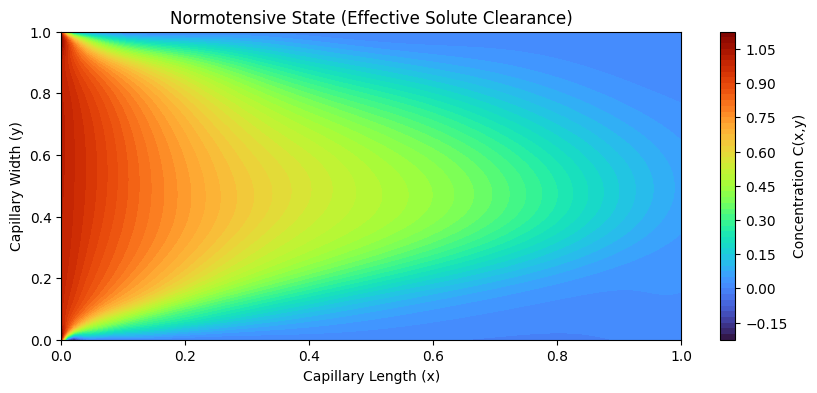

In [15]:
def plot_2d_snapshot(model, title):
    model.eval()
    x = np.linspace(0, 1, 100)
    y = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(x, y)
    x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32)
    y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32)
    t_flat = torch.ones_like(x_flat) # Snapshot at t=1.0
    
    with torch.no_grad():
        C_pred = model(x_flat, y_flat, t_flat).numpy()
        
    C_grid = C_pred.reshape(X.shape)
    
    plt.figure(figsize=(10, 4))
    contour = plt.contourf(X, Y, C_grid, 60, cmap='turbo')
    plt.colorbar(contour, label='Concentration C(x,y)')
    plt.xlabel('Capillary Length (x)')
    plt.ylabel('Capillary Width (y)')
    plt.title(title)
    plt.show()

plot_2d_snapshot(model_healthy, "Normotensive State (Effective Solute Clearance)")

## 2. Hypertensive State (Pathological Simulation)
We train the model with high hydrostatic pressure ($u_{max}=3.5$) and impaired filtration ($k=0.1$).

[+] Training Hypertensive Model...
Training 2D PINN on device: cpu
Epoch 00000 | Total: 41.6137 | Data: 0.2081 | Physics: 0.0009
Epoch 00500 | Total: 6.0111 | Data: 0.0266 | Physics: 0.6894
Epoch 01000 | Total: 3.3980 | Data: 0.0132 | Physics: 0.7527
Epoch 01500 | Total: 2.3165 | Data: 0.0089 | Physics: 0.5266
Epoch 02000 | Total: 1.8431 | Data: 0.0069 | Physics: 0.4687
Epoch 02500 | Total: 1.5689 | Data: 0.0057 | Physics: 0.4296
Epoch 03000 | Total: 1.3077 | Data: 0.0047 | Physics: 0.3635
Epoch 03500 | Total: 1.0340 | Data: 0.0038 | Physics: 0.2747
Epoch 04000 | Total: 0.8032 | Data: 0.0030 | Physics: 0.1989
Epoch 04500 | Total: 0.6489 | Data: 0.0025 | Physics: 0.1465
Epoch 05000 | Total: 0.5354 | Data: 0.0021 | Physics: 0.1122
Epoch 05500 | Total: 0.4461 | Data: 0.0018 | Physics: 0.0815


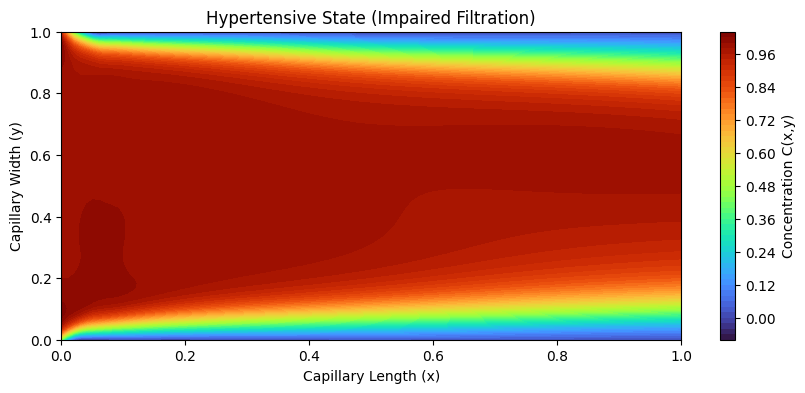

In [16]:
print("[+] Training Hypertensive Model...")
model_diseased = train_pinn(epochs=6000, lr=1e-3, u_max=3.5, D=0.01, k=0.1)

plot_2d_snapshot(model_diseased, "Hypertensive State (Impaired Filtration)")